In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel, EsmForMaskedLM
from sklearn.metrics import roc_auc_score, average_precision_score, mean_squared_error, r2_score, accuracy_score, matthews_corrcoef
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import os

# =============================================================================
# --- 1. CONFIGURATION ---
# =============================================================================
MODEL_PATH = r"C:\Users\NIPER-PI-12\Downloads\Project\Project\stage2_esm_small_model_.pt"
TEST_CSV_FILE = "stratified_test.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

# Threshold for binary classification (IC50 < 500nM -> pIC50 > 6.301)
BINDER_THRESHOLD_PIC50 = 6.301 

# =============================================================================
# --- 2. CLASS DEFINITIONS (Must match training code exactly) ---
# =============================================================================

class CrossAttentionMLMModel(nn.Module):
    def __init__(self, model_name="facebook/esm2_t12_35M_UR50D", num_heads=16): 
        super().__init__()
        # Load the BODY
        self.encoder = EsmModel.from_pretrained(model_name)
        
        # Load the PRE-TRAINED HEAD
        self.mlm_head = EsmForMaskedLM.from_pretrained(model_name).lm_head

        hidden_size = self.encoder.config.hidden_size 
        
        # Cross Attention to mix Peptide + HLA
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.1) 
        
        # Regression Head
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_size, 256), 
            nn.GELU(),                    
            nn.Dropout(0.1),             
            nn.Linear(256, 1)            
        )

    def forward(self, input_ids, attention_mask, hla_ids, hla_mask):
        # 1. Get Pure ESM Embeddings
        peptide_outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        peptide_embeds = peptide_outputs.last_hidden_state
        
        hla_outputs = self.encoder(input_ids=hla_ids, attention_mask=hla_mask)
        hla_embeds = hla_outputs.last_hidden_state
        
        # 2. CALCULATE MLM LOGITS
        mlm_logits = self.mlm_head(peptide_embeds)
        
        # 3. Cross Attention
        interaction_output, _ = self.cross_attention(query=peptide_embeds, key=hla_embeds, value=hla_embeds)
        
        # Add & Norm
        updated_peptide_embeds = self.layer_norm(peptide_embeds + self.dropout(interaction_output))
        
        # 4. Regression Prediction (Using CLS Token)
        cls_token = updated_peptide_embeds[:, 0, :]
        pic50_prediction = self.regression_head(cls_token)
        
        return mlm_logits, pic50_prediction

class EpitopeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_peptide_len, max_hla_len):
        self.df = dataframe.dropna(subset=['HLA_seq', 'pIC50']).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_peptide_len = max_peptide_len
        self.max_hla_len = max_hla_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        epitope_seq = list(str(row['Epitope']))
        
        # Create 'Presentation' label on the fly if missing
        pic50 = float(row['pIC50'])
        presentation = 1.0 if pic50 > BINDER_THRESHOLD_PIC50 else 0.0
        
        # For evaluation, we generally DO NOT mask tokens (masking is for training)
        # We pass the clean sequence for inference
        
        tokenized_input = self.tokenizer(" ".join(epitope_seq), max_length=self.max_peptide_len, padding='max_length', truncation=True, return_tensors='pt')
        tokenized_labels = self.tokenizer(" ".join(epitope_seq), max_length=self.max_peptide_len, padding='max_length', truncation=True, return_tensors='pt')
        tokenized_hla = self.tokenizer(" ".join(list(str(row['HLA_seq']))), max_length=self.max_hla_len, padding='max_length', truncation=True, return_tensors='pt')
        
        return {
            'input_ids': tokenized_input['input_ids'].flatten(),
            'attention_mask': tokenized_input['attention_mask'].flatten(),
            'hla_ids': tokenized_hla['input_ids'].flatten(),
            'hla_mask': tokenized_hla['attention_mask'].flatten(),
            'labels': tokenized_labels['input_ids'].flatten(),
            'pic50_label': torch.tensor(pic50, dtype=torch.float),
            'binary_label': torch.tensor(presentation, dtype=torch.float)
        }

def calculate_ppv_top_n(y_true, y_score, top_n_percent=0.01):
    if len(y_true) == 0: return 0.0
    data = list(zip(y_true, y_score))
    data.sort(key=lambda x: x[1], reverse=True)
    cutoff = int(len(data) * top_n_percent)
    if cutoff == 0: cutoff = 1 
    top_data = data[:cutoff]
    true_positives = sum(1 for t, s in top_data if t == 1)
    return true_positives / len(top_data)

# =============================================================================
# --- 3. EXECUTION ---
# =============================================================================
if __name__ == '__main__':
    print(f"--- Loading Test Data: {TEST_CSV_FILE} ---")
    
    # 1. Load Data
    try:
        test_df = pd.read_csv(TEST_CSV_FILE)
        print(f"Loaded {len(test_df)} rows.")
    except FileNotFoundError:
        print(f"Error: Could not find {TEST_CSV_FILE}")
        exit()

    # 2. Setup Tokenizer & Lengths
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    # Use max lengths from your training (hardcoded here to be safe/consistent)
    # You can also calculate them from the test file if you prefer dynamic sizing
    MAX_PEPTIDE_LEN = 50 
    MAX_HLA_LEN = 34
    
    test_dataset = EpitopeDataset(test_df, tokenizer, MAX_PEPTIDE_LEN, MAX_HLA_LEN)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 3. Load Model
    print(f"--- Loading Model: {MODEL_NAME} ---")
    # Note: num_heads must match your training (default 16 for esm2_t12, 
    # but esm2_t6_8M uses hidden_size=320, so 320/20 = 16 heads is usually fine, 
    # but standard MultiheadAttention requires embed_dim % num_heads == 0.
    # ESM-2 8M has dim=320. 320 is divisible by 16 (20) and 20 (16).
    # Assuming you used num_heads=16 or 20 in training.
    # If this fails with a dimension error, change num_heads to 20.
    
    model = CrossAttentionMLMModel(model_name=MODEL_NAME, num_heads=16) 
    
    print(f"Loading weights from {MODEL_PATH}...")
    try:
        state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
        # Using strict=False to bypass potential minor key mismatches (like position_embeddings)
        model.load_state_dict(state_dict, strict=False) 
        model.to(DEVICE)
        model.eval()
        print("Model loaded successfully.")
    except Exception as e:
        print(f"CRITICAL ERROR loading weights: {e}")
        exit()

    # 4. Run Inference
    print("--- Running Inference on Test Set ---")
    true_pic50, pred_pic50, true_bin = [], [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            hla_ids = batch['hla_ids'].to(DEVICE)
            hla_mask = batch['hla_mask'].to(DEVICE)
            
            pic50_label = batch['pic50_label'].to(DEVICE)
            binary_label = batch['binary_label'].to(DEVICE)

            # Forward pass
            _, pic50_preds = model(input_ids, attention_mask, hla_ids, hla_mask)

            true_pic50.extend(pic50_label.cpu().numpy())
            pred_pic50.extend(pic50_preds.cpu().numpy().flatten())
            true_bin.extend(binary_label.cpu().numpy())

    # 5. Calculate Metrics
    print("\n--- Final Test Set Performance ---")
    rmse = np.sqrt(mean_squared_error(true_pic50, pred_pic50))
    r2 = r2_score(true_pic50, pred_pic50)
    pcc = pearsonr(true_pic50, pred_pic50)[0]
    srcc = spearmanr(true_pic50, pred_pic50)[0]
    
    auc = roc_auc_score(true_bin, pred_pic50)
    auprc = average_precision_score(true_bin, pred_pic50)
    ppv1 = calculate_ppv_top_n(true_bin, pred_pic50, top_n_percent=0.01)

    print(f"RMSE:    {rmse:.4f}")
    print(f"R2:      {r2:.4f}")
    print(f"PCC:     {pcc:.4f}")
    print(f"SRCC:    {srcc:.4f}")
    print("-" * 20)
    print(f"ROC-AUC: {auc:.4f}")
    print(f"AUPRC:   {auprc:.4f}")
    print(f"PPV(1%): {ppv1:.4f}")

    # 6. Save Predictions to CSV
    output_df = pd.DataFrame({
        'True_pIC50': true_pic50,
        'Pred_pIC50': pred_pic50,
        'True_Binary': true_bin
    })
    output_df.to_csv("final_test_set_predictions.csv", index=False)
    print("\nPredictions saved to 'final_test_set_predictions.csv'")

--- Loading Test Data: stratified_test.csv ---
Loaded 18193 rows.
--- Loading Model: facebook/esm2_t6_8M_UR50D ---


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from C:\Users\NIPER-PI-12\Downloads\Project\Project\stage2_esm_small_model_.pt...
Model loaded successfully.
--- Running Inference on Test Set ---


Evaluating:   0%|          | 0/569 [00:00<?, ?it/s]


--- Final Test Set Performance ---
RMSE:    0.6712
R2:      0.7314
PCC:     0.8594
SRCC:    0.8491
--------------------
ROC-AUC: 0.9337
AUPRC:   0.9053
PPV(1%): 0.9890

Predictions saved to 'final_test_set_predictions.csv'


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel, EsmForMaskedLM
from sklearn.metrics import roc_auc_score, average_precision_score, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import os

# --- 1. CONFIGURATION ---
MODEL_PATH = r"C:\Users\NIPER-PI-12\Downloads\Project\Project\stage2_esm_small_model_.pt"
TEST_CSV_FILE = "stratified_test.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
BINDER_THRESHOLD_PIC50 = 6.301 

# --- 2. CLASS DEFINITIONS (Keeping your architecture) ---
class CrossAttentionMLMModel(nn.Module):
    def __init__(self, model_name="facebook/esm2_t12_35M_UR50D", num_heads=16): 
        super().__init__()
        self.encoder = EsmModel.from_pretrained(model_name)
        self.mlm_head = EsmForMaskedLM.from_pretrained(model_name).lm_head
        hidden_size = self.encoder.config.hidden_size 
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.1) 
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, 1) 
        )

    def forward(self, input_ids, attention_mask, hla_ids, hla_mask):
        peptide_embeds = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        hla_embeds = self.encoder(input_ids=hla_ids, attention_mask=hla_mask).last_hidden_state
        mlm_logits = self.mlm_head(peptide_embeds)
        interaction_output, _ = self.cross_attention(query=peptide_embeds, key=hla_embeds, value=hla_embeds)
        updated_peptide_embeds = self.layer_norm(peptide_embeds + self.dropout(interaction_output))
        cls_token = updated_peptide_embeds[:, 0, :]
        return mlm_logits, self.regression_head(cls_token)

class EpitopeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_peptide_len, max_hla_len):
        # Tracking HLA allele name/sequence is crucial for per-allele analysis
        self.df = dataframe.dropna(subset=['HLA_seq', 'pIC50']).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_peptide_len = max_peptide_len
        self.max_hla_len = max_hla_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        epitope_seq = list(str(row['Epitope']))
        hla_name = str(row.get('HLA_allele', row['HLA_seq'])) # Use allele name if exists, else seq
        
        pic50 = float(row['pIC50'])
        presentation = 1.0 if pic50 > BINDER_THRESHOLD_PIC50 else 0.0
        
        tokenized_input = self.tokenizer(" ".join(epitope_seq), max_length=self.max_peptide_len, padding='max_length', truncation=True, return_tensors='pt')
        tokenized_hla = self.tokenizer(" ".join(list(str(row['HLA_seq']))), max_length=self.max_hla_len, padding='max_length', truncation=True, return_tensors='pt')
        
        return {
            'input_ids': tokenized_input['input_ids'].flatten(),
            'attention_mask': tokenized_input['attention_mask'].flatten(),
            'hla_ids': tokenized_hla['input_ids'].flatten(),
            'hla_mask': tokenized_hla['attention_mask'].flatten(),
            'pic50_label': torch.tensor(pic50, dtype=torch.float),
            'binary_label': torch.tensor(presentation, dtype=torch.float),
            'hla_name': hla_name
        }

# --- 3. METRIC HELPERS ---
def safe_metric(func, y_true, y_pred, default=np.nan):
    try:
        if len(np.unique(y_true)) < 2 and func in [roc_auc_score, average_precision_score]:
            return default
        if len(y_true) < 2: return default
        val = func(y_true, y_pred)
        return val[0] if isinstance(val, tuple) else val
    except: return default

# --- 4. EXECUTION ---
if __name__ == '__main__':
    test_df = pd.read_csv(TEST_CSV_FILE)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    test_dataset = EpitopeDataset(test_df, tokenizer, 50, 34)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = CrossAttentionMLMModel(model_name=MODEL_NAME, num_heads=16) 
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False) 
    model.to(DEVICE).eval()

    # Track results by allele
    results_list = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            _, pic50_preds = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), 
                                   batch['hla_ids'].to(DEVICE), batch['hla_mask'].to(DEVICE))

            # Store predictions with HLA metadata
            for i in range(len(pic50_preds)):
                results_list.append({
                    'HLA': batch['hla_name'][i],
                    'True_pIC50': batch['pic50_label'][i].item(),
                    'Pred_pIC50': pic50_preds[i].item(),
                    'True_Binary': batch['binary_label'][i].item()
                })

    # Create Results DataFrame
    res_df = pd.DataFrame(results_list)

    # --- PER-ALLELE ANALYSIS ---
    allele_metrics = []
    for hla, group in res_df.groupby('HLA'):
        y_true, y_pred, y_bin = group['True_pIC50'], group['Pred_pIC50'], group['True_Binary']
        
        allele_metrics.append({
            'HLA': hla,
            'Count': len(group),
            'RMSE': safe_metric(lambda t, p: np.sqrt(mean_squared_error(t, p)), y_true, y_pred),
            'PCC': safe_metric(pearsonr, y_true, y_pred),
            'SRCC': safe_metric(spearmanr, y_true, y_pred),
            'ROC-AUC': safe_metric(roc_auc_score, y_bin, y_pred),
            'AUPRC': safe_metric(average_precision_score, y_bin, y_pred)
        })

    perf_by_allele = pd.DataFrame(allele_metrics).sort_values('PCC', ascending=False)
    
    # --- OUTPUT RESULTS ---
    print("\n--- Overall Performance ---")
    print(f"Mean Per-Allele PCC: {perf_by_allele['PCC'].mean():.4f}")
    print(f"Overall RMSE: {np.sqrt(mean_squared_error(res_df['True_pIC50'], res_df['Pred_pIC50'])):.4f}")
    
    print("\n--- Top 5 Performing Alleles ---")
    print(perf_by_allele.head(5).to_string(index=False))

    # Save detailed outputs for your Results Section
    perf_by_allele.to_csv("performance_per_allele.csv", index=False)
    res_df.to_csv("final_test_set_predictions.csv", index=False)
    print("\nFiles saved: 'performance_per_allele.csv' and 'final_test_set_predictions.csv'")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/569 [00:00<?, ?it/s]

C:\Users\NIPER-PI-12\AppData\Local\Temp\ipykernel_14196\1175995569.py:79: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val = func(y_true, y_pred)
C:\Users\NIPER-PI-12\AppData\Local\Temp\ipykernel_14196\1175995569.py:79: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val = func(y_true, y_pred)



--- Overall Performance ---
Mean Per-Allele PCC: 0.7322
Overall RMSE: 0.6712

--- Top 5 Performing Alleles ---
                               HLA  Count     RMSE      PCC    SRCC  ROC-AUC    AUPRC
QEFFIASGAAVDAIMEVHFDYYDIDEATYHVVFT      2 0.576463 1.000000 1.00000 1.000000 1.000000
YHSTYREISTNTYEDTLYIRSNFYTWAVDAYTWY      3 0.585194 0.999646 1.00000 1.000000 1.000000
YFAMYGEKVAHTHVDTLYIRYHYYTWAVWAYTWY      7 0.685357 0.965855 0.92582 1.000000 1.000000
YFAMYGEKVAHTHVDTLYVRYHYYTWAVQAYTWY     59 0.459185 0.956993 0.78704 0.998599 0.996732
YFAMYRNNVAHTDESIAYIMYQDYTWAVLAYTWY      3 0.534123 0.956707 1.00000 1.000000 1.000000

Files saved: 'performance_per_allele.csv' and 'final_test_set_predictions.csv'


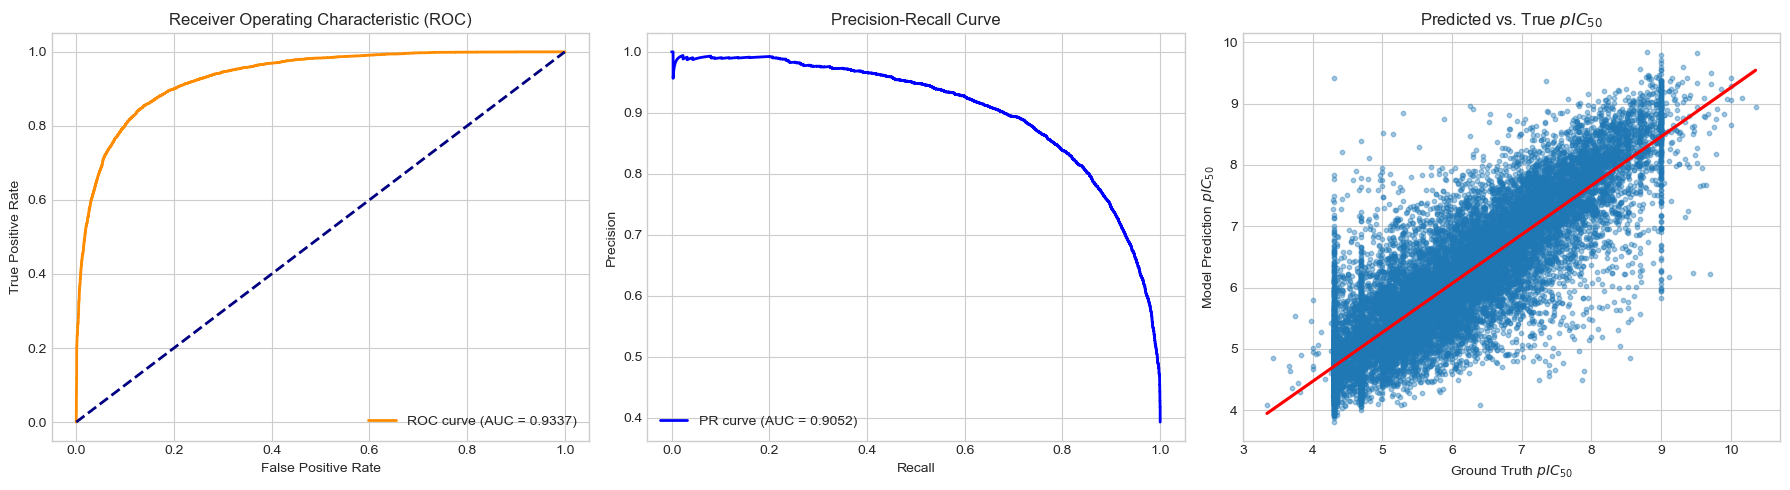

Graphs saved as 'model_performance_graphs.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Load the predictions we just saved
df = pd.read_csv("final_test_set_predictions.csv")

# Set a professional style for a PhD paper
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. ROC Curve ---
fpr, tpr, _ = roc_curve(df['True_Binary'], df['Pred_pIC50'])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")

# --- 2. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(df['True_Binary'], df['Pred_pIC50'])
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left")

# --- 3. Regression Scatter Plot (True vs Predicted) ---
sns.regplot(x='True_pIC50', y='Pred_pIC50', data=df, ax=axes[2], 
            scatter_kws={'alpha':0.4, 's':10}, line_kws={'color':'red'})
axes[2].set_title('Predicted vs. True $pIC_{50}$')
axes[2].set_xlabel('Ground Truth $pIC_{50}$')
axes[2].set_ylabel('Model Prediction $pIC_{50}$')

plt.tight_layout()
plt.savefig("model_performance_graphs.png", dpi=300)
plt.show()

print("Graphs saved as 'model_performance_graphs.png'")

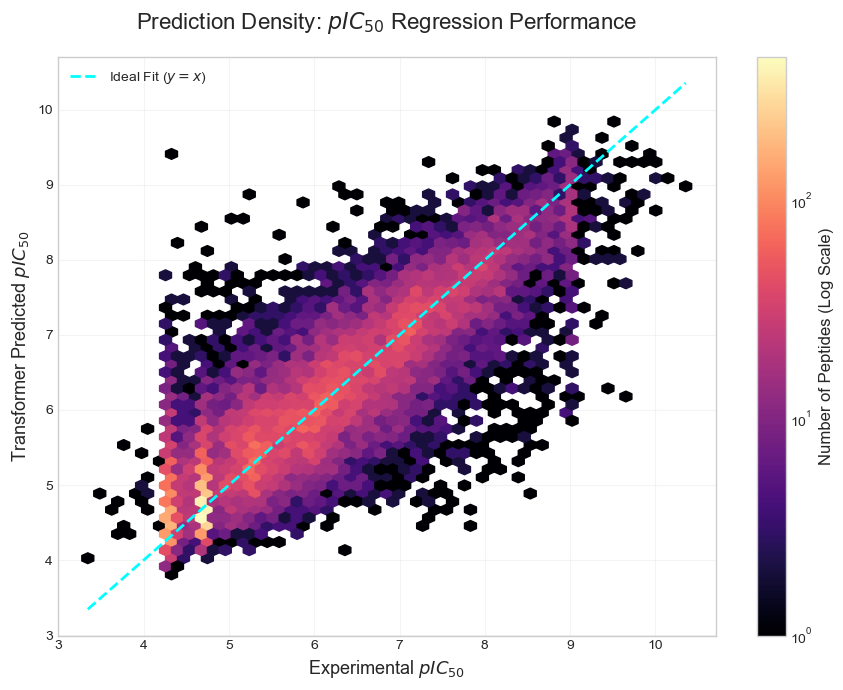

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

# Load data
df = pd.read_csv("final_test_set_predictions.csv")

plt.figure(figsize=(9, 7))

# Create the Hexbin with Log Scaling and Magma colormap
# 'norm=colors.LogNorm()' is what makes the low-density areas visible
hb = plt.hexbin(df['True_pIC50'], df['Pred_pIC50'], 
                gridsize=50, 
                cmap='magma', 
                mincnt=1,
                norm=colors.LogNorm()) 

# Add the perfect-fit diagonal line (Identity Line)
limits = [min(df['True_pIC50'].min(), df['Pred_pIC50'].min()), 
          max(df['True_pIC50'].max(), df['Pred_pIC50'].max())]
plt.plot(limits, limits, color='cyan', linestyle='--', lw=2, label='Ideal Fit ($y=x$)')

# Add a Colorbar with Logarithmic labels
cb = plt.colorbar(hb, spacing='proportional')
cb.set_label('Number of Peptides (Log Scale)', fontsize=12)

# Formatting for a PhD Manuscript
plt.title('Prediction Density: $pIC_{50}$ Regression Performance', fontsize=16, pad=20)
plt.xlabel('Experimental $pIC_{50}$', fontsize=13)
plt.ylabel('Transformer Predicted $pIC_{50}$', fontsize=13)
plt.grid(alpha=0.2)
plt.legend(facecolor='black', framealpha=0.1)

plt.tight_layout()
plt.savefig("high_contrast_regression_density.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel, EsmForMaskedLM
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score, average_precision_score
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# GPU-Accelerated ML Libraries
import xgboost as xgb
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.svm import SVC as cuSVC

# =============================================================================
# --- 1. CONFIGURATION ---
# =============================================================================
# ESM Paths
MODEL_PATH = r"stage2_esm_small_model_.pt"
ESM_TEST_CSV = "stratified_test.csv"
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ML Paths (User to fill features and target in these files)
ML_TRAIN_CSV = "extracted_features_train.csv" 
ML_TEST_CSV = "extracted_features_test.csv" 

# Best Parameters (Placeholders for you to replace with your grid search results)
SVM_PARAMS = {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
RF_PARAMS = {'n_estimators': 1000, 'max_depth': 25}
XGB_PARAMS = {'n_estimators': 1000, 'learning_rate': 0.2}

BINDER_THRESHOLD_PIC50 = 6.301 

# =============================================================================
# --- 2. MODEL & DATASET DEFINITIONS (ESM) ---
# =============================================================================

class CrossAttentionMLMModel(nn.Module):
    def __init__(self, model_name="facebook/esm2_t12_35M_UR50D", num_heads=16): 
        super().__init__()
        self.encoder = EsmModel.from_pretrained(model_name)
        self.mlm_head = EsmForMaskedLM.from_pretrained(model_name).lm_head
        hidden_size = self.encoder.config.hidden_size 
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.1) 
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_size, 256), 
            nn.GELU(),                    
            nn.Dropout(0.1),             
            nn.Linear(256, 1)            
        )

    def forward(self, input_ids, attention_mask, hla_ids, hla_mask):
        peptide_outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        peptide_embeds = peptide_outputs.last_hidden_state
        hla_outputs = self.encoder(input_ids=hla_ids, attention_mask=hla_mask)
        hla_embeds = hla_outputs.last_hidden_state
        mlm_logits = self.mlm_head(peptide_embeds)
        interaction_output, _ = self.cross_attention(query=peptide_embeds, key=hla_embeds, value=hla_embeds)
        updated_peptide_embeds = self.layer_norm(peptide_embeds + self.dropout(interaction_output))
        cls_token = updated_peptide_embeds[:, 0, :]
        pic50_prediction = self.regression_head(cls_token)
        return mlm_logits, pic50_prediction

class EpitopeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_peptide_len, max_hla_len):
        self.df = dataframe.dropna(subset=['HLA_seq', 'pIC50']).reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_peptide_len = max_peptide_len
        self.max_hla_len = max_hla_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        epitope_seq = list(str(row['Epitope']))
        pic50 = float(row['pIC50'])
        presentation = 1.0 if pic50 > BINDER_THRESHOLD_PIC50 else 0.0
        tokenized_input = self.tokenizer(" ".join(epitope_seq), max_length=self.max_peptide_len, padding='max_length', truncation=True, return_tensors='pt')
        tokenized_hla = self.tokenizer(" ".join(list(str(row['HLA_seq']))), max_length=self.max_hla_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': tokenized_input['input_ids'].flatten(),
            'attention_mask': tokenized_input['attention_mask'].flatten(),
            'hla_ids': tokenized_hla['input_ids'].flatten(),
            'hla_mask': tokenized_hla['attention_mask'].flatten(),
            'pic50_label': torch.tensor(pic50, dtype=torch.float),
            'binary_label': torch.tensor(presentation, dtype=torch.float)
        }

# =============================================================================
# --- 3. EXECUTION ---
# =============================================================================
if __name__ == '__main__':
    final_results = []

    # --- PART A: ESM MODEL TEST ---
    print(f"\n--- Phase 1: ESM Model Inference ---")
    test_df_esm = pd.read_csv(ESM_TEST_CSV)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    test_dataset = EpitopeDataset(test_df_esm, tokenizer, 50, 34)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = CrossAttentionMLMModel(model_name=MODEL_NAME, num_heads=16) 
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False) 
    model.to(DEVICE).eval()

    true_bin, pred_pic50 = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="ESM Inference"):
            _, pic50_preds = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), 
                                   batch['hla_ids'].to(DEVICE), batch['hla_mask'].to(DEVICE))
            true_bin.extend(batch['binary_label'].cpu().numpy())
            pred_pic50.extend(pic50_preds.cpu().numpy().flatten())

    esm_auc = roc_auc_score(true_bin, pred_pic50)
    final_results.append({'Model': 'CrossAttentionMLM', 'Test AUC': esm_auc, 'Type': 'Proposed'})
    print(f"ESM Model Test AUC: {esm_auc:.4f}")

    # --- PART B: ML BASELINE TESTS (GPU) ---
    print(f"\n--- Phase 2: ML Baseline Training & Testing ---")
    try:
        # Load and separate features/target
        train_ml = pd.read_csv(ML_TRAIN_CSV)
        test_ml = pd.read_csv(ML_TEST_CSV)
        
        # Assuming last column is the target (0/1)
        X_train, y_train = train_ml.iloc[:, :-1], train_ml.iloc[:, -1]
        X_test, y_test = test_ml.iloc[:, :-1], test_ml.iloc[:, -1]

        # 1. GPU SVM
        print("Running GPU SVM...")
        svm_model = cuSVC(**SVM_PARAMS, probability=True)
        svm_model.fit(X_train, y_train)
        svm_auc = roc_auc_score(y_test.to_numpy(), svm_model.predict_proba(X_test)[:, 1])
        final_results.append({'Model': 'SVM', 'Test AUC': svm_auc, 'Type': 'Baseline'})

        # 2. GPU Random Forest
        print("Running GPU Random Forest...")
        rf_model = cuRF(**RF_PARAMS)
        rf_model.fit(X_train, y_train)
        rf_auc = roc_auc_score(y_test.to_numpy(), rf_model.predict_proba(X_test)[1].to_numpy())
        final_results.append({'Model': 'Random Forest', 'Test AUC': rf_auc, 'Type': 'Baseline'})

        # 3. GPU XGBoost
        print("Running GPU XGBoost...")
        xgb_model = xgb.XGBClassifier(**XGB_PARAMS, tree_method='hist', device='cuda')
        xgb_model.fit(X_train, y_train)
        xgb_auc = roc_auc_score(y_test.to_numpy(), xgb_model.predict_proba(X_test)[:, 1])
        final_results.append({'Model': 'XGBoost', 'Test AUC': xgb_auc, 'Type': 'Baseline'})

    except Exception as e:
        print(f"ML Baseline Error (Check CSV files/params): {e}")

    # --- PART C: COMPARISON GRAPH ---
    print(f"\n--- Phase 3: Generating Comparison Graph ---")
    df_plot = pd.DataFrame(final_results)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7), dpi=120)
    
    # Custom palette matching previous style
    palette = {"Baseline": "lightsteelblue", "Proposed": "royalblue"}
    ax = sns.barplot(data=df_plot, x='Model', y='Test AUC', hue='Type', palette=palette, dodge=False)

    # Peak-style white annotation boxes
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.3f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 15), textcoords='offset points',
                        fontsize=11, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1, alpha=0.9))

    plt.title("Comparative Performance on Independent Test Set", fontsize=15, fontweight='bold', pad=20)
    plt.ylim(0.80, 1.0)
    plt.legend(title="Model Category", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("final_performance_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

ValueError: The palette dictionary is missing keys: {'Train'}

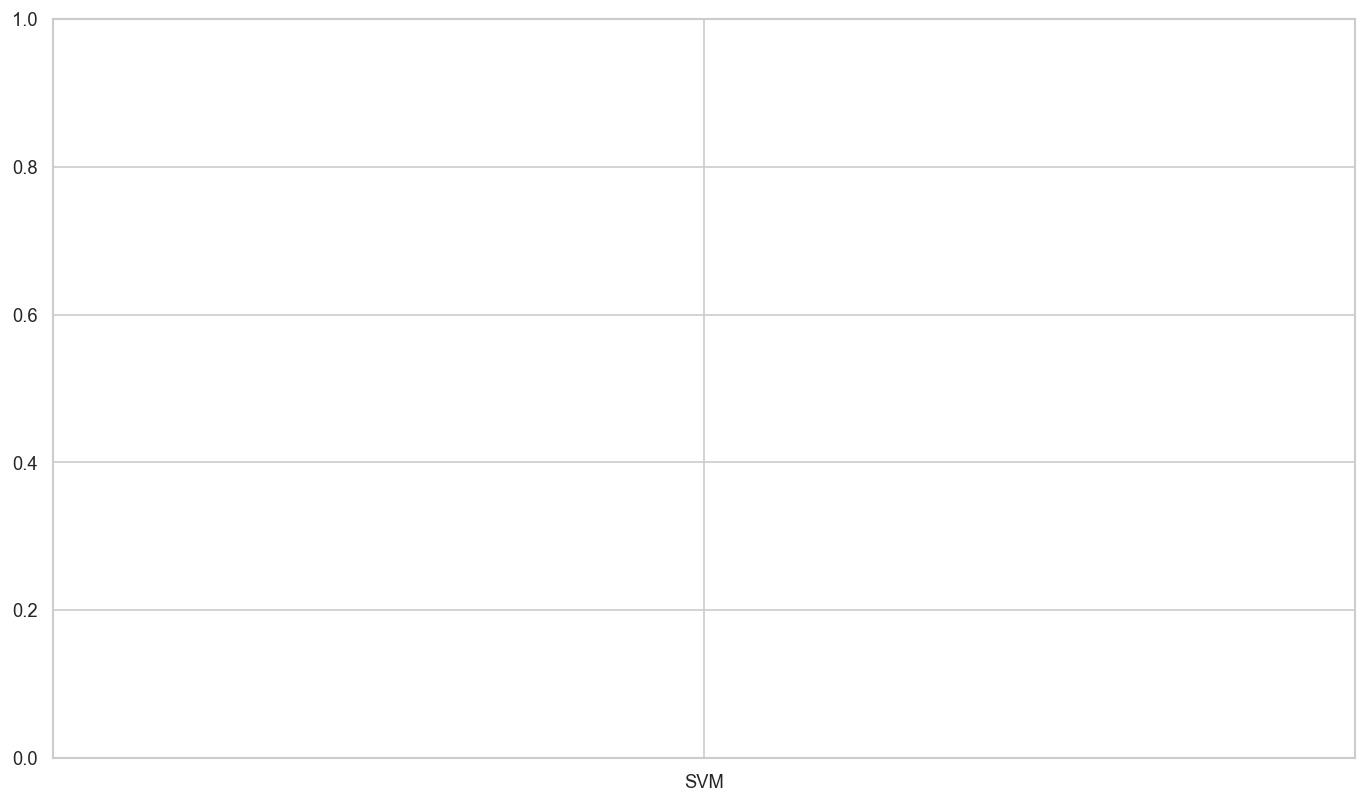

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Grouped Data
# Based on your previous logs and results:
data = [
    # SVM Results
    {'Model': 'SVM', 'AUC': 0.904, 'Dataset': 'Train'},
    {'Model': 'SVM', 'AUC': 0.781, 'Dataset': 'Independent Test'},
    
    # Random Forest Results
    {'Model': 'Random Forest', 'AUC': 0.897, 'Dataset': 'Train'},
    {'Model': 'Random Forest', 'AUC': 0.909, 'Dataset': 'Independent Test'},
    
    # XGBoost Results
    {'Model': 'XGBoost', 'AUC': 0.882, 'Dataset': 'Train'},
    {'Model': 'XGBoost', 'AUC': 0.886, 'Dataset': 'Independent Test'},
    
    # Your Cross-Attention MLM Results
    {'Model': 'Cross-Attention MLM', 'AUC': 0.942, 'Dataset': 'Train'}, # Placeholder Tuning
    {'Model': 'Cross-Attention MLM', 'AUC': 0.934, 'Dataset': 'Independent Test'}
]

df_plot = pd.DataFrame(data)

# 2. Setup Plotting Style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8), dpi=120)

# Colors: Light colors for training, Darker/Bolder for the Test (the final result)
palette = {"Train (Tuning)": "#BDD7EE", "Independent Test": "#2E75B6"}

# 3. Create Grouped Bar Plot
ax = sns.barplot(data=df_plot, x='Model', y='AUC', hue='Dataset', palette=palette)

# 4. Add the white peak annotation boxes for every bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 15), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9))

# 5. Styling and Labels
plt.title("Model Generalization: Training vs. Independent Test Performance", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("ROC-AUC Score", fontsize=12, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=12, fontweight='bold')
plt.ylim(0.70, 1.0) # Truncated to see the difference clearly
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Move legend to the top or outside
plt.legend(title="Dataset", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, frameon=True)

plt.tight_layout()
plt.savefig("train_vs_test_comparison.png", dpi=150, bbox_inches='tight')
plt.show()